# TRM Evaluation Analysis

In [20]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob

## README

Assumes that the batch size is 1 of the trajectory.

Otherwise, we would need to unwind the representation. 

In [21]:
# 1. Input Paths
# Set these variables manually based on the logs generated by your eval_trm run.
batch_id = "5a29cc67"

################ the path to the trajectories folder # ##################

base_dir = "../output/qm9/runs/latent recursion n0 M8 z64 null cond/val_trm_trajectories" 

x_t_path = os.path.join(base_dir, f"X_t_batch_{batch_id}.pt")
x_1_path = os.path.join(base_dir, f"X_1_batch_{batch_id}.pt")
val_datapoint_path = os.path.join(base_dir, f"val_datapoint_batch_{batch_id}.pt")

In [22]:
# 2. Load Data and Print Basic Shapes & Statistics
print("--- Loading X_t, X_1, and Ground Truth ---")
try:
    x_t_data = torch.load(x_t_path, map_location="cpu")
    print(f"X_t sequence length (timesteps): {len(x_t_data['pos'])}")
    if len(x_t_data['pos']) > 0:
        print(f"  X_t pos shape: {x_t_data['pos'][0].shape}")
        if len(x_t_data['h']) > 0: print(f"  X_t h shape: {x_t_data['h'][0].shape}")
except Exception as e:
    print(f"Could not load X_t: {e}")

try:
    x_1_data = torch.load(x_1_path, map_location="cpu")
    print(f"\nX_1 sequence length (timesteps): {len(x_1_data['pos'])}")
    if len(x_1_data['pos']) > 0:
        print(f"  X_1 pos shape: {x_1_data['pos'][0].shape}")
        if len(x_1_data['h']) > 0: print(f"  X_1 h shape: {x_1_data['h'][0].shape}")
except Exception as e:
    print(f"Could not load X_1: {e}")

try:
    val_data = torch.load(val_datapoint_path, map_location="cpu")
    print(f"\nGround Truth loaded: {val_data['pos'].shape}")
except Exception as e:
    print(f"Could not load val_datapoint: {e}")

print("\n--- Loading Z Data ---")
z_files = glob.glob(os.path.join(base_dir, f"Z_*_batch_{batch_id}.pt"))
z_files.sort() 

Z_iters = []
for f in z_files:
    z_list = torch.load(f, map_location="cpu")
    Z_iters.append(z_list)
    print(f"Loaded {os.path.basename(f)}: contains {len(z_list)} timesteps")

--- Loading X_t, X_1, and Ground Truth ---
X_t sequence length (timesteps): 250
  X_t pos shape: torch.Size([8, 18, 3])
  X_t h shape: torch.Size([8, 18])

X_1 sequence length (timesteps): 250
  X_1 pos shape: torch.Size([8, 18, 3])

Ground Truth loaded: torch.Size([8, 18, 3])

--- Loading Z Data ---
Loaded Z_0_batch_5a29cc67.pt: contains 250 timesteps


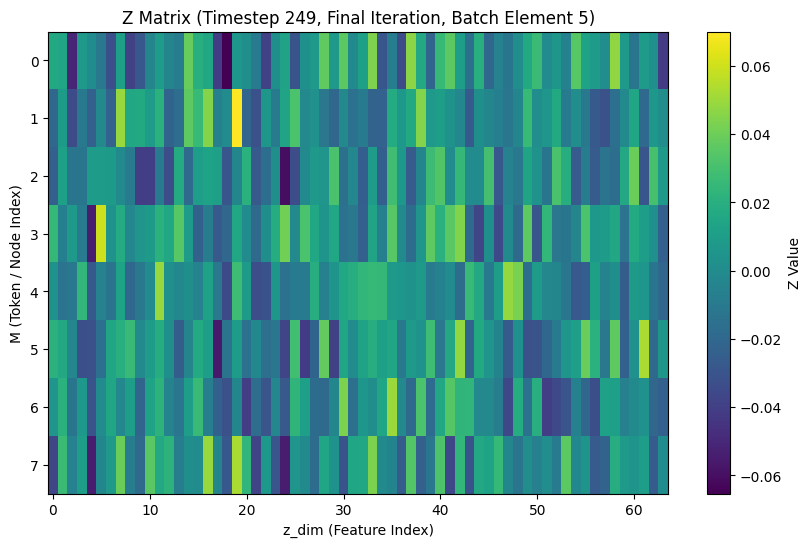

In [23]:
# 3. Plot Z as a Matrix
# Visualizing the final iteration (Z_last) at the first sampling timestep

# Z_iters:   (n x t x b x M x z_dim)

latent_recursion_step = 0
timestep = 249
batch_element = 5
if Z_iters:
    z_example = Z_iters[latent_recursion_step][timestep][batch_element] # Final iteration, first timestep. Shape: (B, M, z_dim)
    

    z_matrix = z_example.numpy() 
    plt.figure(figsize=(10, 6))
    plt.imshow(z_matrix, aspect='auto', cmap='viridis')
    plt.colorbar(label="Z Value")
    plt.title(f"Z Matrix (Timestep {timestep}, Final Iteration, Batch Element {batch_element})")
    plt.xlabel("z_dim (Feature Index)")
    plt.ylabel("M (Token / Node Index)")
    plt.show()
else:
    print("Cannot plot: Z data is empty.")

In [12]:
z_example[:,0]

tensor([ 0.0171, -0.0196, -0.0238,  0.0247,  0.0038,  0.0213,  0.0055, -0.0368])

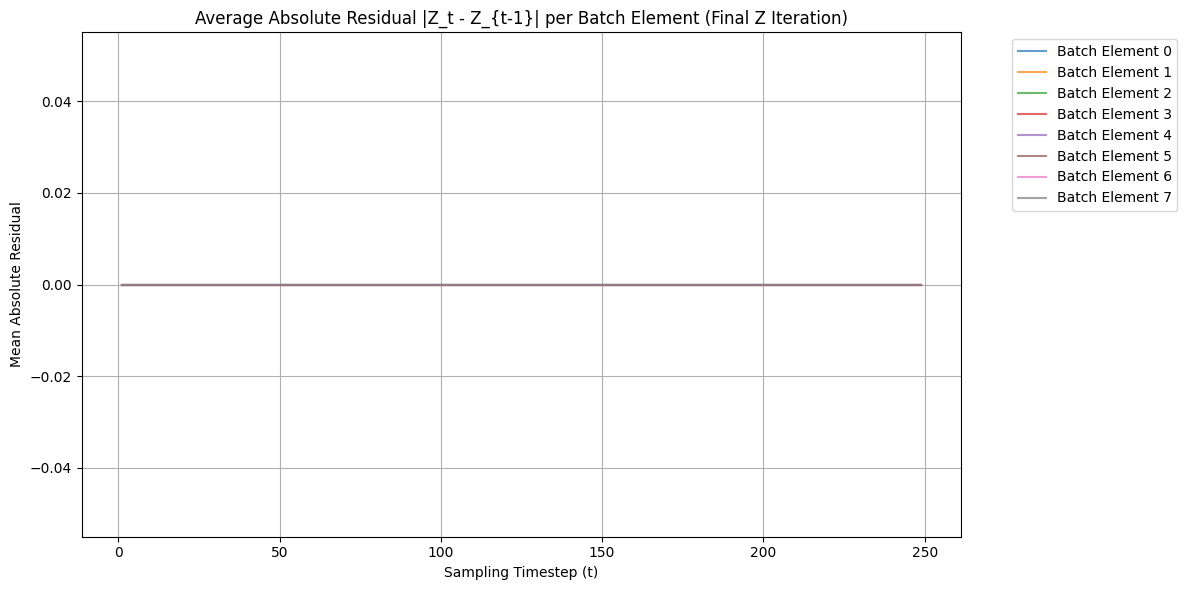

In [13]:
# 4. Plot Average Absolute Residual |Z_t - Z_{t-1}| Across Timesteps


if Z_iters and len(Z_iters[0]) > 1:
    # Using the final iteration of latent recursion
    Z_final_traj = Z_iters[0] 
    T = len(Z_final_traj)
    B = Z_final_traj[0].shape[0]
    
    residuals = np.zeros((B, T - 1))
    
    for t in range(1, T):
        Z_prev = Z_final_traj[t-1].numpy()
        Z_curr = Z_final_traj[t].numpy()
        
        # Absolute residual
        diff = np.abs(Z_curr - Z_prev)
        
        # Average across the M and z_dim dimensions
        avg_diff = np.mean(diff, axis=(1, 2))
        residuals[:, t-1] = avg_diff
        
    plt.figure(figsize=(12, 6))
    for b in range(B):
        plt.plot(range(1, T), residuals[b, :], alpha=0.7, label=f"Batch Element {b}")
        
    plt.title("Average Absolute Residual |Z_t - Z_{t-1}| per Batch Element (Final Z Iteration)")
    plt.xlabel("Sampling Timestep (t)")
    plt.ylabel("Mean Absolute Residual")
    if B <= 12: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough timesteps to compute residuals.")

--- Loading Z trajectory from: ../output/qm9/runs/2026-04-20_15-14-31/val_trm_trajectories/Z_0_batch_5a29cc67.pt ---
Plotting for Batch Element 0 | Path: Z_0_batch_5a29cc67.pt
Shape: 250 timesteps, 8 batch, 8 tokens, 64 dimensions


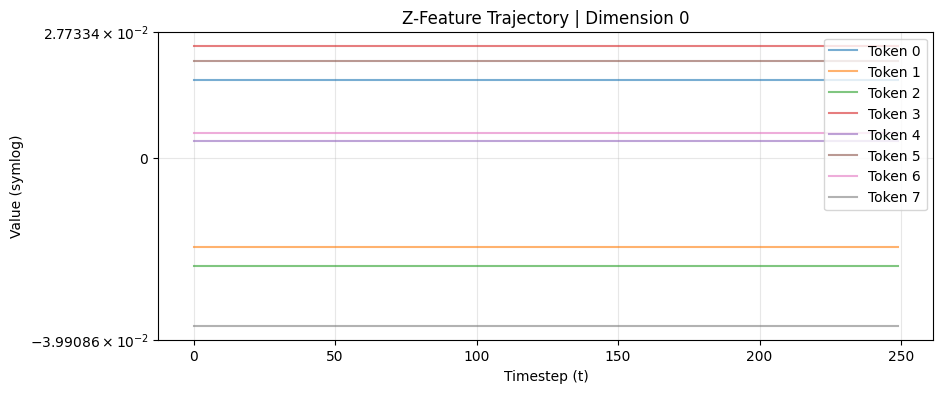

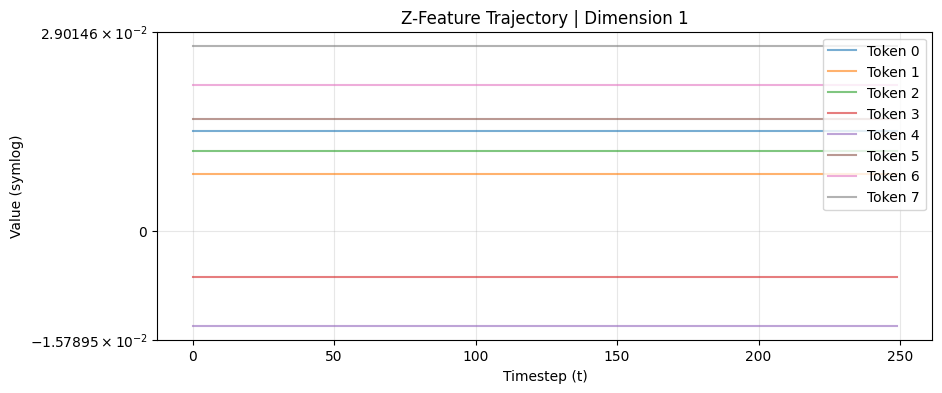

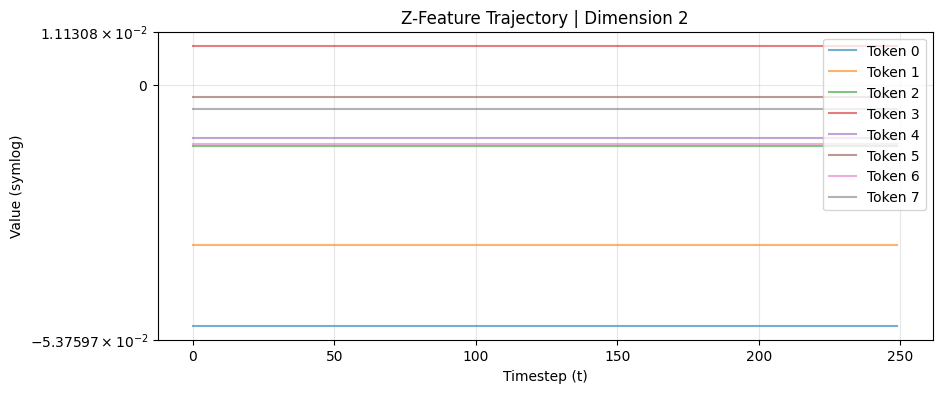

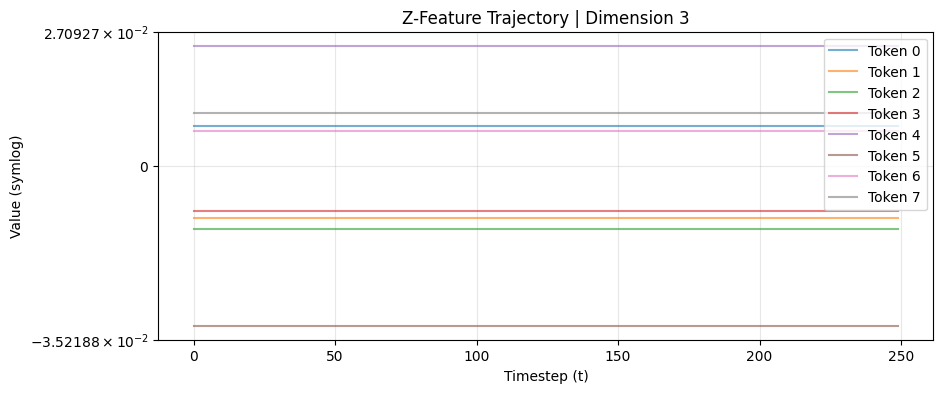

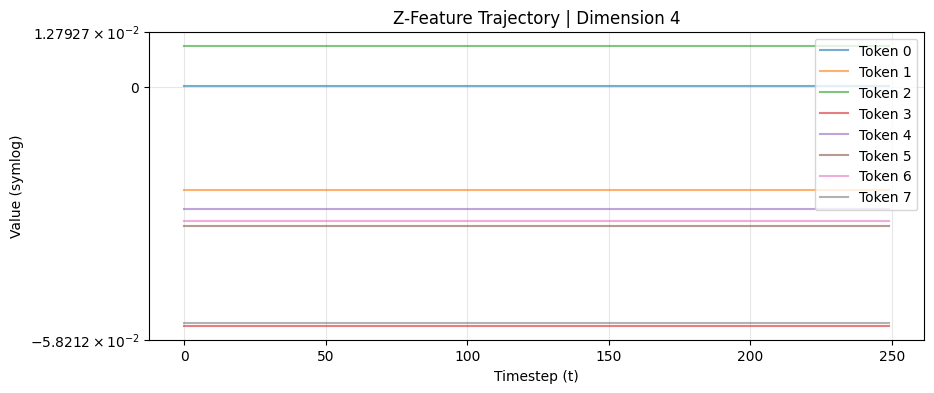

In [14]:
# 5. Value Trajectories over Timesteps
# Plotted for a single batch element. Shows Z feature values over time.

z_path = os.path.join(base_dir, f"Z_0_batch_{batch_id}.pt") # Start with Z_0
batch_idx = 0 # Manual control for batch element

print(f"--- Loading Z trajectory from: {z_path} ---")
z_traj = torch.load(z_path, map_location="cpu") # List of (B, M, z_dim)
z_traj_tensor = torch.stack(z_traj) # (T, B, M, z_dim)

T, B, M, D = z_traj_tensor.shape
print(f"Plotting for Batch Element {batch_idx} | Path: {os.path.basename(z_path)}")
print(f"Shape: {T} timesteps, {B} batch, {M} tokens, {D} dimensions")

# We will produce D (likely 64) plots.
# To keep it readable in a notebook, we can use a small grid or just print them.
# Note: 64 plots can be heavy, let's plot them in a scrollable block (default notebook behavior)

for d in range(min(D, 5)): #change to D if we want all
    plt.figure(figsize=(10, 4))
    # For this dimension d, plot all M tokens
    data_to_plot = z_traj_tensor[:, batch_idx, :, d].numpy() # (T, M)
    
    for m in range(M):
        plt.plot(range(T), data_to_plot[:, m], alpha=0.6, label=f"Token {m}" if M <= 10 else None)
    
    plt.title(f"Z-Feature Trajectory | Dimension {d}")
    plt.xlabel("Timestep (t)")
    plt.yscale('symlog')
    plt.ylabel("Value (symlog)")
    if M <= 10: plt.legend(loc='upper right')
    plt.grid(True, which='both', alpha=0.3)
    plt.show()

# 5. Trajectory Visualizations

In this section, we visualize the 3D trajectory of the atoms for both $x_t$ and $x_1$ over time.

In [15]:
# Configuration and Atom Decoding
batch_element = 0  # <--- Change this if there are multiple molecules in the batch

# Correct mapping for QM9 based on atomic numbers (Z):
# 1:H, 6:C, 7:N, 8:O, 9:F
idx_to_symbol = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
color_map = {'H': 'white', 'C': 'gray', 'N': 'blue', 'O': 'red', 'F': 'green'}

# Get atom identities from x_t_data['h']
h_indices = x_t_data['h'][0].cpu().numpy()
atom_symbols = [idx_to_symbol.get(int(i), '?') for i in h_indices]

print(f"Atoms: {', '.join(atom_symbols)}")

# Prepare trajectories as numpy arrays (T, N, 3)
X_t_traj = torch.stack(x_t_data['pos']).cpu().numpy() # [T, N, 3]
X_1_traj = torch.stack(x_1_data['pos']).cpu().numpy() # [T, N, 3]

print(f"Trajectory shapes: X_t {X_t_traj.shape}, X_1 {X_1_traj.shape}")

TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
from ipywidgets import interact, IntSlider
import numpy as np

# Force rendering mode that doesn't require nbformat
pio.renderers.default = "notebook_connected" 

# Map colors for Plotly
plotly_colors = {'H': 'white', 'C': 'silver', 'N': 'royalblue', 'O': 'red', 'F': 'green'}

def plotly_3d_plot(trajectory, title_prefix, limit=5.0):
    def update(timestep):
        pos = trajectory[timestep]
        fig = go.Figure()
        
        # Add atoms
        for i, s in enumerate(atom_symbols):
            color = plotly_colors.get(s, 'gray')
            fig.add_trace(go.Scatter3d(
                x=[pos[i, 0]], y=[pos[i, 1]], z=[pos[i, 2]],
                mode='markers+text',
                marker=dict(size=12, color=color, line=dict(width=2, color='black'), opacity=0.8),
                text=[s],
                textfont=dict(size=12, color='black'),
                textposition="top center",
                name=s,
                showlegend=False
            ))
            
        fig.update_layout(
            title=f"{title_prefix} (t={timestep})",
            scene=dict(
                xaxis=dict(range=[-limit, limit], title="X (Å)"),
                yaxis=dict(range=[-limit, limit], title="Y (Å)"),
                zaxis=dict(range=[-limit, limit], title="Z (Å)"),
                aspectmode='cube'
            ),
            width=800, height=600,
            margin=dict(l=0, r=0, b=0, t=50)
        )
        fig.show()

    interact(update, timestep=IntSlider(min=0, max=len(trajectory)-1, step=1, value=0, description='Timestep'))

def plotly_static_plot(pos, title, limit=5.0):
    fig = go.Figure()
    for i, s in enumerate(atom_symbols):
        color = plotly_colors.get(s, 'gray')
        fig.add_trace(go.Scatter3d(
            x=[pos[i, 0]], y=[pos[i, 1]], z=[pos[i, 2]],
            mode='markers+text',
            marker=dict(size=12, color=color, line=dict(width=2, color='black'), opacity=0.8),
            text=[s],
            textfont=dict(size=12, color='black'),
            textposition="top center",
            showlegend=False
        ))
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[-limit, limit], title="X (Å)"),
            yaxis=dict(range=[-limit, limit], title="Y (Å)"),
            zaxis=dict(range=[-limit, limit], title="Z (Å)"),
            aspectmode='cube'
        ),
        width=800, height=600
    )
    fig.show()

print("Molecular Visualizations (Rotatable 3D View):")

# 1. Plot Ground Truth
if 'val_data' in locals():
    print("Visualizing Actual Molecule (Ground Truth):")
    plotly_static_plot(val_data['pos'].cpu().numpy(), "Ground Truth Molecule")

# 2. Plot Trajectories (Interactive & Rotatable)
print("\nInteractive Trajectories (Drag to rotate, scroll to zoom):")
plotly_3d_plot(X_t_traj, "X_t Trajectory")
plotly_3d_plot(X_1_traj, "X_1 Trajectory")

Molecular Visualizations (Rotatable 3D View):
Visualizing Actual Molecule (Ground Truth):



Interactive Trajectories (Drag to rotate, scroll to zoom):


interactive(children=(IntSlider(value=0, description='Timestep', max=249), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=0, description='Timestep', max=249), Output()), _dom_classes=('widget-in…

# 6. Interatomic Distance Evolution

Analysis of pairwise interatomic distances over time using specified intervals.

Plotting distances for BONDED atom pairs ONLY:


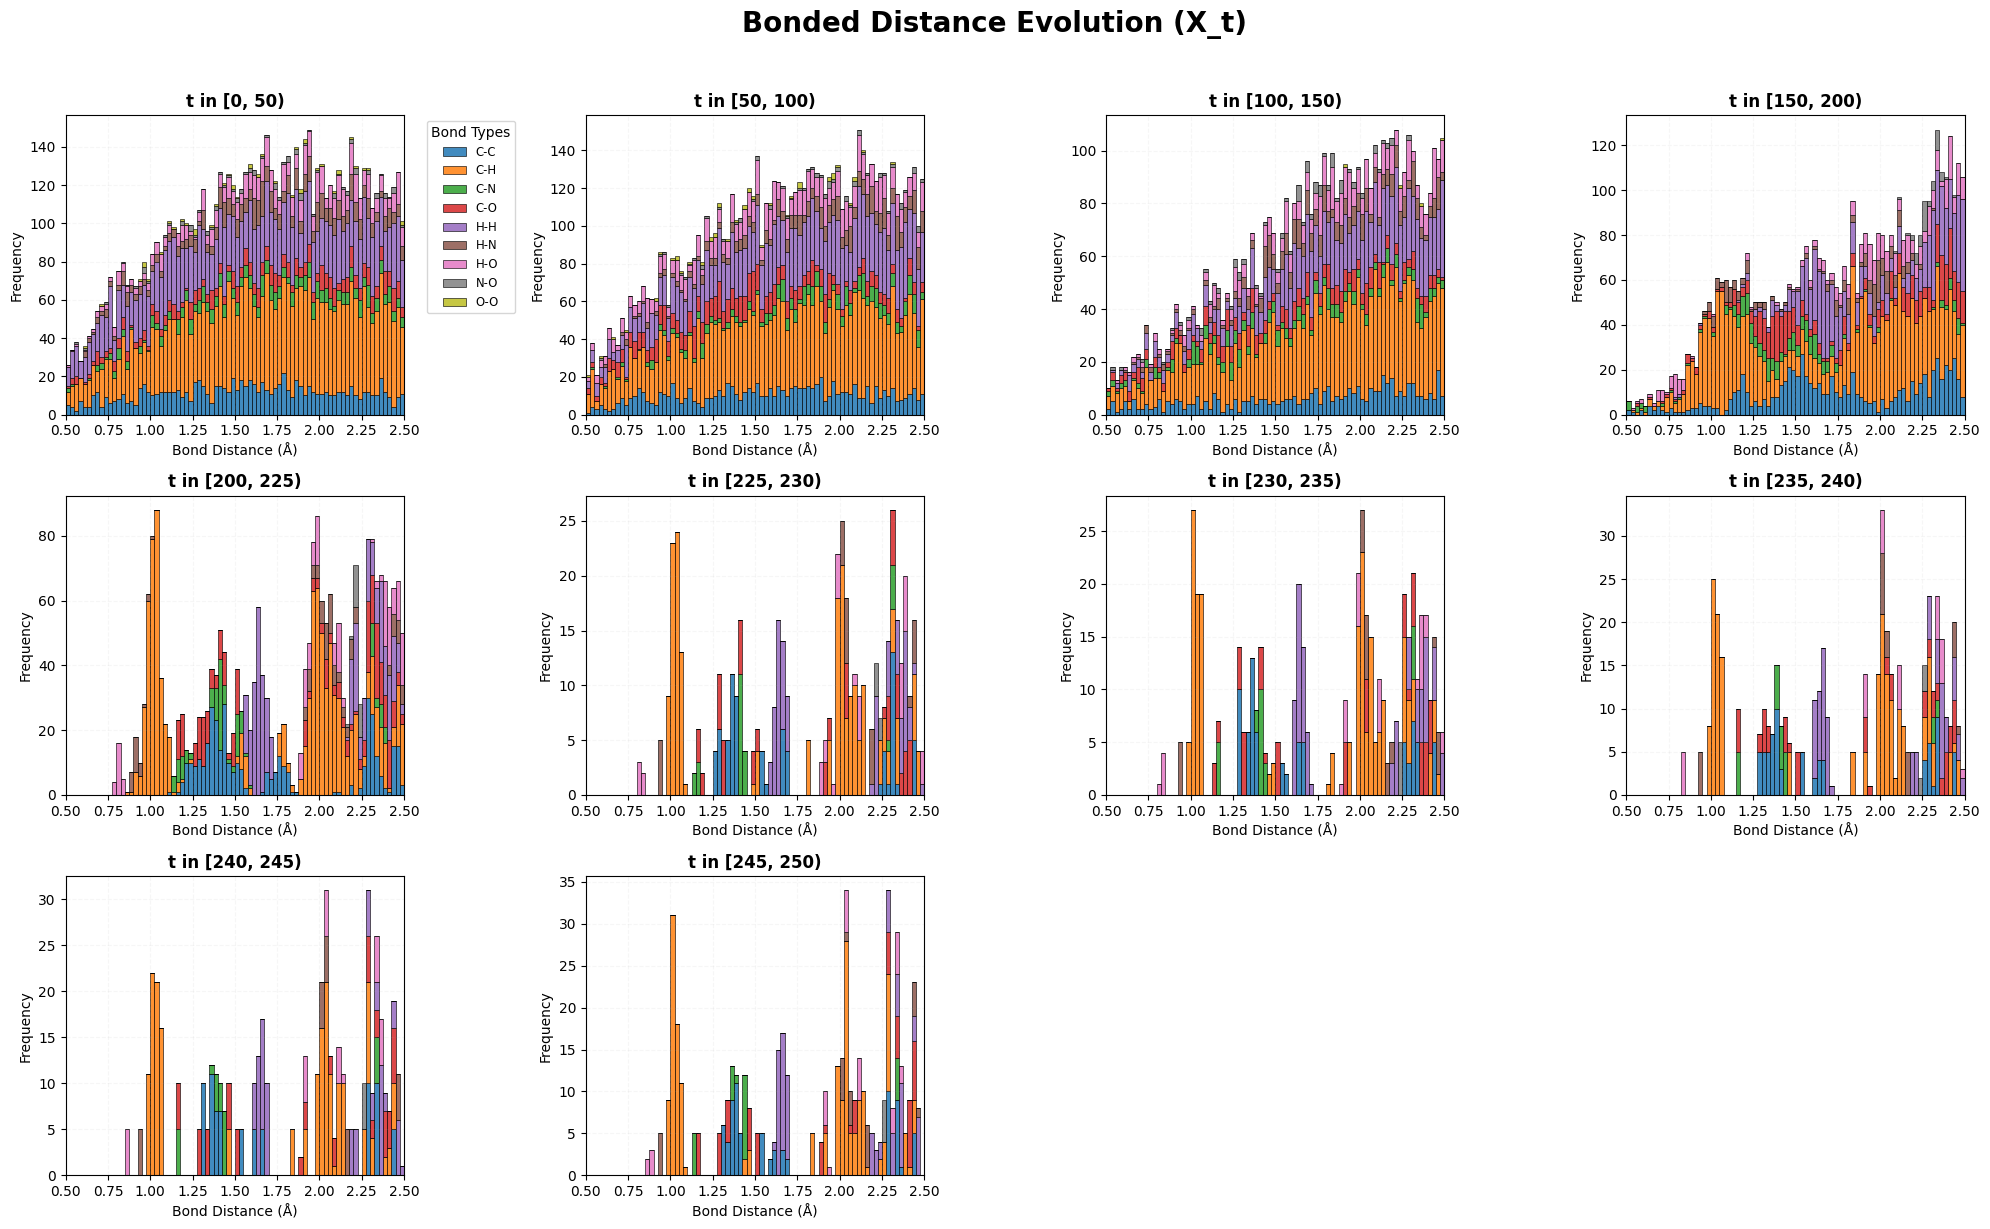

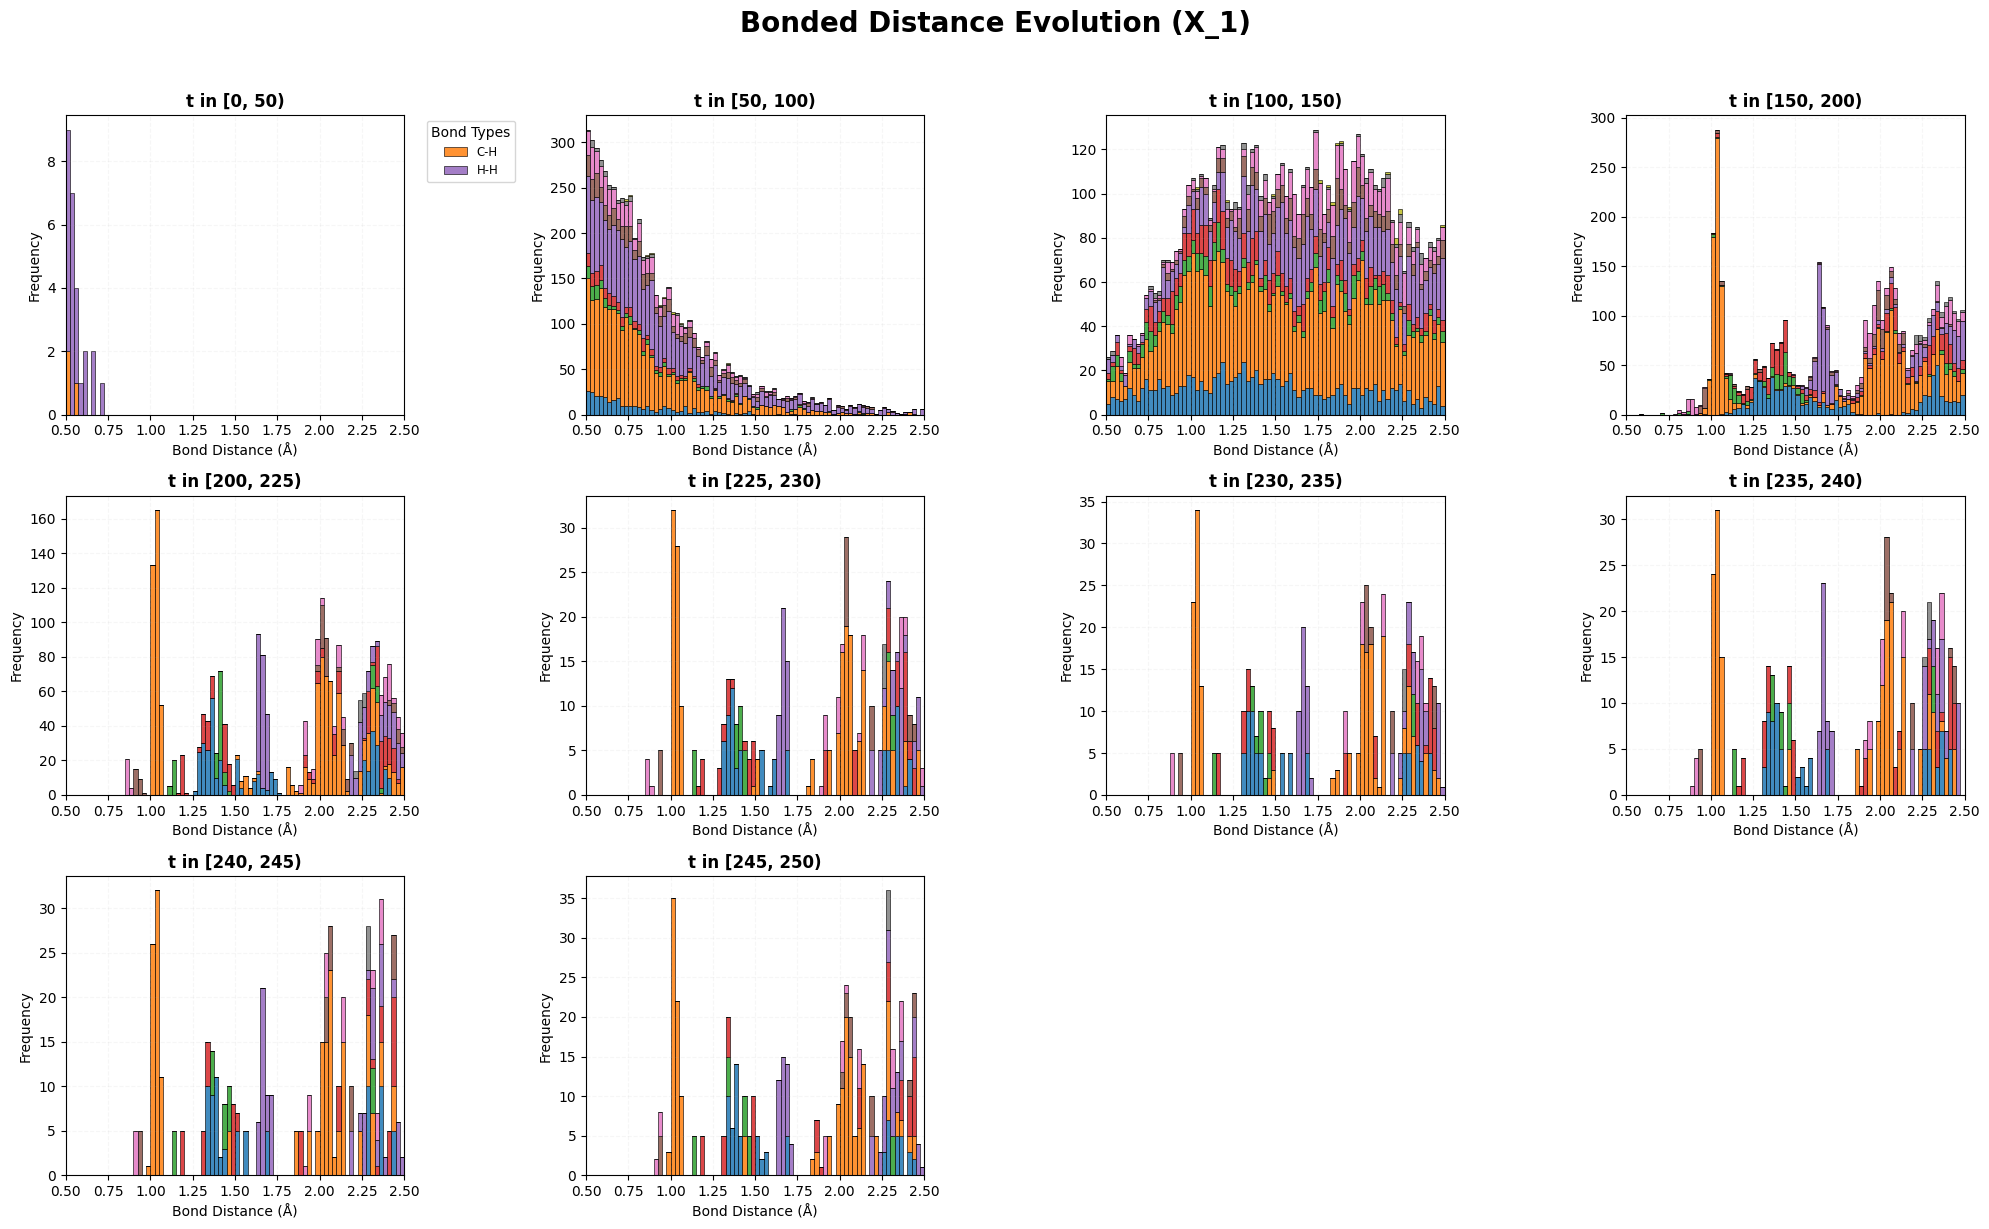

In [ ]:
def get_bonded_distances(traj_pos, atom_symbols, edge_node_index):
    T, N, _ = traj_pos.shape
    
    # edge_node_index is [2, E]. Extract unique undirected bonds.
    edges = edge_node_index.cpu().numpy()
    unique_bonds = set()
    for k in range(edges.shape[1]):
        u, v = edges[0, k], edges[1, k]
        if u < v:
            unique_bonds.add((u, v))
            
    pair_data = [] # List of (dist_trajectory, symbol_pair_string)
    for (i, j) in unique_bonds:
        s1, s2 = atom_symbols[i], atom_symbols[j]
        pair_string = "-".join(sorted((s1, s2)))
        
        # Compute distance trajectory for this bonded pair
        dist_traj = np.linalg.norm(traj_pos[:, i, :] - traj_pos[:, j, :], axis=-1)
        pair_data.append((dist_traj, pair_string))
        
    return pair_data

def plot_distance_histogram_trajectory(traj_pos, atom_symbols, edge_node_index, title="Bonded Distance Evolution"):
    T_total = traj_pos.shape[0]
    pair_data = get_bonded_distances(traj_pos, atom_symbols, edge_node_index)
    
    if not pair_data:
        print(f"No bonds found to plot for {title}")
        return

    # Filtering Range: 0.5 to 2.5 Angstrom, 0.025 bin width
    d_min, d_max = 0.5, 2.5
    bin_width = 0.025
    bins = np.arange(d_min, d_max + bin_width, bin_width)
    
    # Time intervals
    intervals = [(0, 50), (50, 100), (100, 150), (150, 200), (200, 225)]
    for t in range(225, T_total, 5):
        intervals.append((t, min(t+5, T_total)))
    
    n_plots = len(intervals)
    n_cols = 4
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    # Consistent colors for pair types
    unique_pair_types = sorted(list(set(p[1] for p in pair_data)))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    type_to_color = {pt: color_cycle[k % len(color_cycle)] for k, pt in enumerate(unique_pair_types)}

    for idx, (t_start, t_end) in enumerate(intervals):
        ax = axes[idx]
        data_by_type = {pt: [] for pt in unique_pair_types}
        
        for dist_traj, pt in pair_data:
            interval_vals = dist_traj[t_start:t_end]
            valid_vals = interval_vals[(interval_vals >= d_min) & (interval_vals <= d_max)]
            data_by_type[pt].extend(valid_vals)
            
        plot_data = [data_by_type[pt] for pt in unique_pair_types if len(data_by_type[pt]) > 0]
        plot_labels = [pt for pt in unique_pair_types if len(data_by_type[pt]) > 0]
        plot_colors = [type_to_color[pt] for pt in unique_pair_types if len(data_by_type[pt]) > 0]
        
        if plot_data:
            ax.hist(plot_data, bins=bins, stacked=True, label=plot_labels, color=plot_colors, 
                    alpha=0.85, edgecolor='black', linewidth=0.5)
        
        ax.set_title(f"t in [{t_start}, {t_end})", fontsize=12, fontweight='bold')
        ax.set_xlim(d_min, d_max)
        ax.set_xlabel("Bond Distance (Å)")
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.1, linestyle='--')
        if idx == 0:
            ax.legend(title="Bond Types", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle(title, fontsize=20, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the visualization using the edge index from val_data
if 'val_data' in locals():
    print("Plotting distances for BONDED atom pairs ONLY:")
    edges = val_data['edge_node_index']
    plot_distance_histogram_trajectory(X_t_traj, atom_symbols, edges, title="Bonded Distance Evolution (X_t)")
    plot_distance_histogram_trajectory(X_1_traj, atom_symbols, edges, title="Bonded Distance Evolution (X_1)")
else:
    print("val_data not found. Run the loading cells first.")

## Inspect model parameters 

In [ ]:
ckpt_path = '../output/qm9/runs/latent recursion n0 M8 z64 null cond/checkpoints/last.ckpt'
ckpt = torch.load(ckpt_path, map_location='cpu')
state_dict = ckpt['state_dict']


print("Unique keys for LatentSyncModule Layer 0:")
for key in state_dict.keys():
    if key.startswith('model_ema.module.parameterization.encoder.latent_sync_modules.0.'):
        print(f"  - {key.split(layer_0_prefix)[1]}")

Unique keys for LatentSyncModule Layer 0:
  - read_attn.q_proj_weight
  - read_attn.k_proj_weight
  - read_attn.v_proj_weight
  - read_attn.in_proj_bias
  - read_attn.out_proj.weight
  - read_attn.out_proj.bias
  - read_mlp.weight
  - read_mlp.bias
  - encoder_layer.self_attn.in_proj_weight
  - encoder_layer.self_attn.in_proj_bias
  - encoder_layer.self_attn.out_proj.weight
  - encoder_layer.self_attn.out_proj.bias
  - encoder_layer.linear1.weight
  - encoder_layer.linear1.bias
  - encoder_layer.linear2.weight
  - encoder_layer.linear2.bias
  - encoder_layer.norm1.weight
  - encoder_layer.norm1.bias
  - encoder_layer.norm2.weight
  - encoder_layer.norm2.bias
  - transformer_blocks.layers.0.self_attn.in_proj_weight
  - transformer_blocks.layers.0.self_attn.in_proj_bias
  - transformer_blocks.layers.0.self_attn.out_proj.weight
  - transformer_blocks.layers.0.self_attn.out_proj.bias
  - transformer_blocks.layers.0.linear1.weight
  - transformer_blocks.layers.0.linear1.bias
  - transformer

## 4. Latent Recursion Parameter Analysis

To inspect the learned parameter values of the `latent_sync_modules` (Latent Recursion), we can:
1. Load the checkpoint's `state_dict`.
2. Extract the weights for each depth ($k=0 \dots 8$) separating the components:
   - **Read**: `read_attn`, `read_mlp`, `norm_read.scaling`
   - **Compute**: `encoder_layer`, `norm_compute.scaling`
   - **Write**: `write_attn`, `write_mlp`
3. Compute the L2 norm (or mean absolute value) for the weights to see how much magnitude the network places on read vs compute vs write across recursion depths.
4. Plot the progression over depth.

Unique keys for LatentSyncModule Layer 0:
  - read_attn.q_proj_weight
  - read_attn.k_proj_weight
  - read_attn.v_proj_weight
  - read_attn.in_proj_bias
  - read_attn.out_proj.weight
  - read_attn.out_proj.bias
  - read_mlp.weight
  - read_mlp.bias
  - encoder_layer.self_attn.in_proj_weight
  - encoder_layer.self_attn.in_proj_bias
  - encoder_layer.self_attn.out_proj.weight
  - encoder_layer.self_attn.out_proj.bias
  - encoder_layer.linear1.weight
  - encoder_layer.linear1.bias
  - encoder_layer.linear2.weight
  - encoder_layer.linear2.bias
  - encoder_layer.norm1.weight
  - encoder_layer.norm1.bias
  - encoder_layer.norm2.weight
  - encoder_layer.norm2.bias
  - transformer_blocks.layers.0.self_attn.in_proj_weight
  - transformer_blocks.layers.0.self_attn.in_proj_bias
  - transformer_blocks.layers.0.self_attn.out_proj.weight
  - transformer_blocks.layers.0.self_attn.out_proj.bias
  - transformer_blocks.layers.0.linear1.weight
  - transformer_blocks.layers.0.linear1.bias
  - transformer

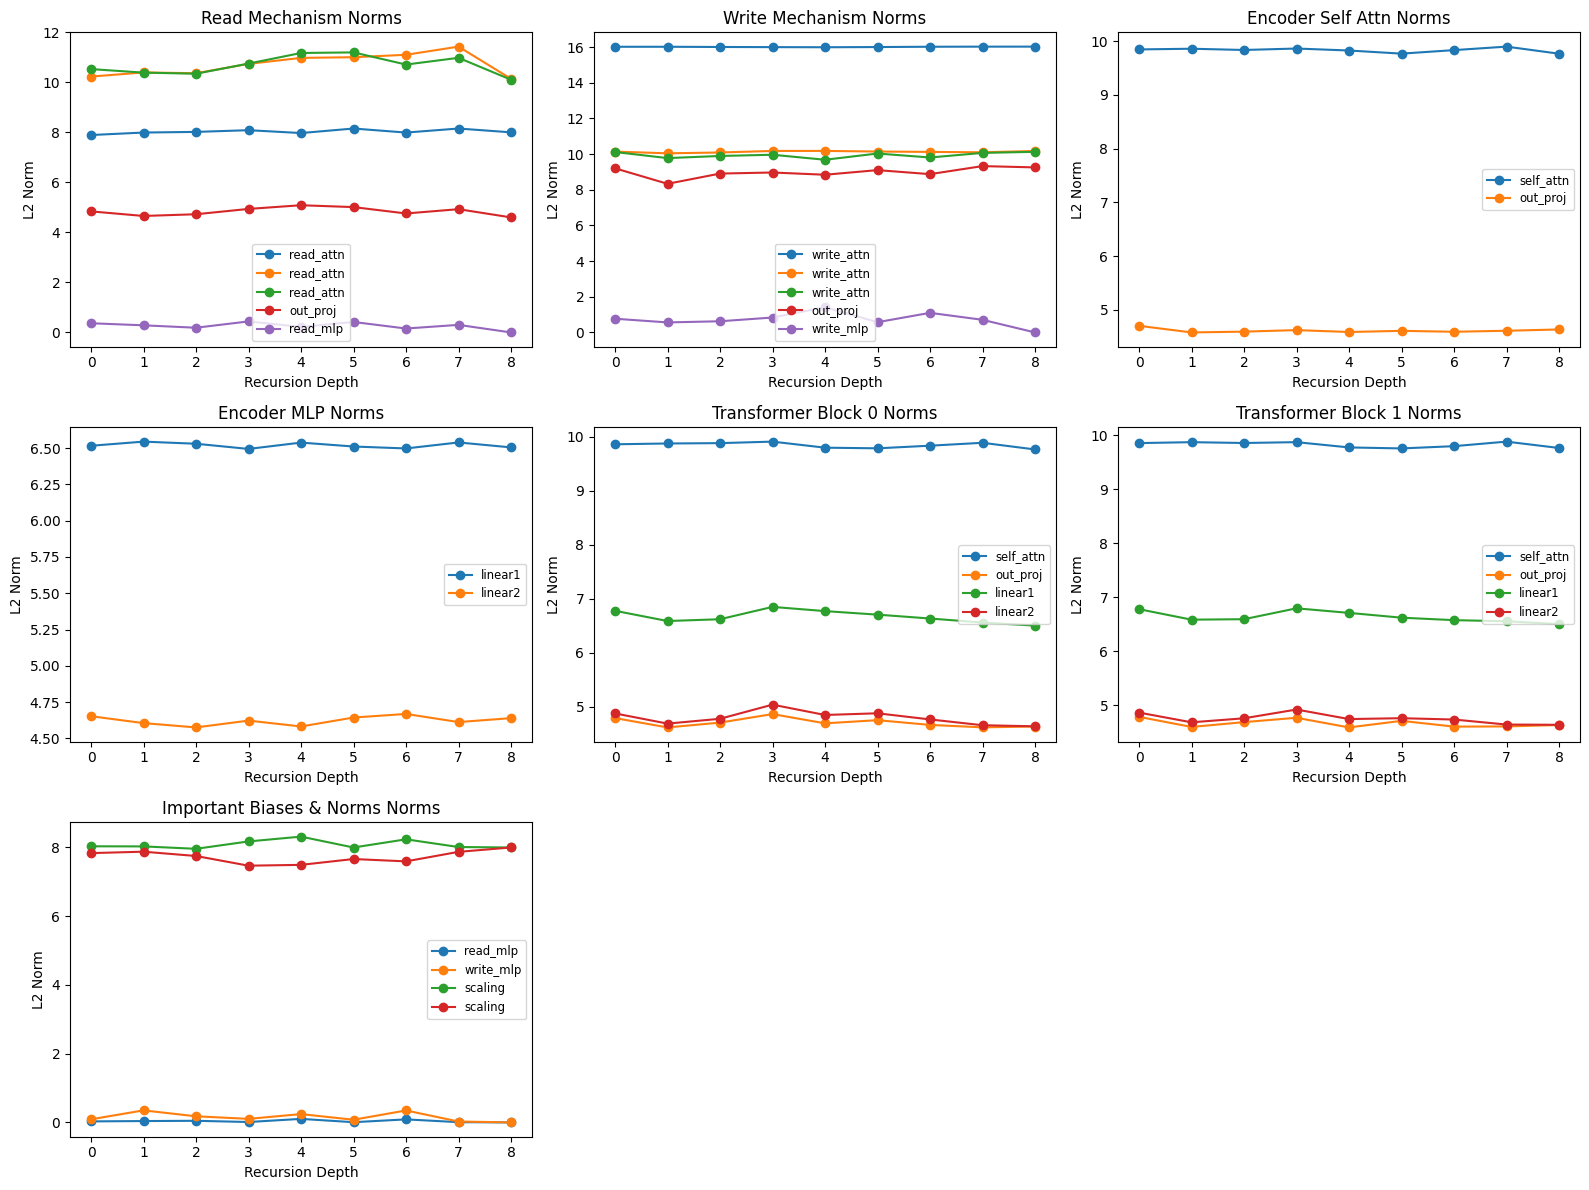

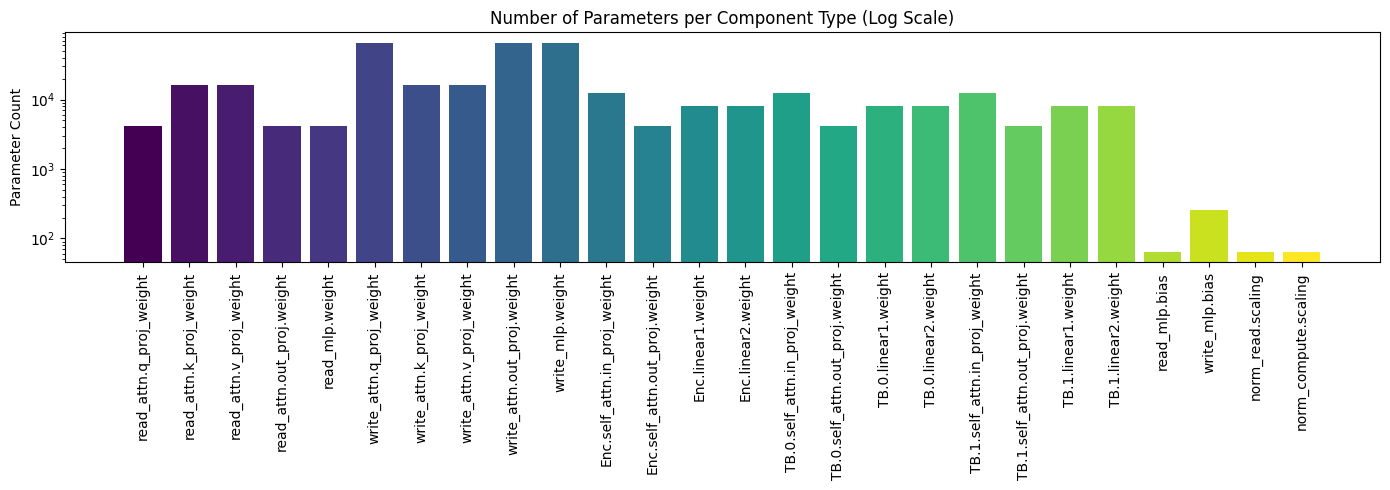

In [50]:
import torch
import matplotlib.pyplot as plt
import numpy as np

ckpt_path = '../output/qm9/runs/latent recursion n0 M8 z64 null cond/checkpoints/last.ckpt'
ckpt = torch.load(ckpt_path, map_location='cpu')
state_dict = ckpt['state_dict']

print("Unique keys for LatentSyncModule Layer 0:")
layer_0_prefix = 'model_ema.module.parameterization.encoder.latent_sync_modules.0.'
for key in state_dict.keys():
    if key.startswith(layer_0_prefix):
        print(f"  - {key.split(layer_0_prefix)[1]}")

# Helper function to plot all grouped components natively over depth
def plot_parameter_metrics(state_dict, prefix_template, num_layers, component_groups):
    layers = np.arange(num_layers)
    n_cols = 3
    n_rows = int(np.ceil(len(component_groups) / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axs = axs.flatten()
    
    param_counts = {}
    
    # 1. Parameter Norms per layer
    for ax_idx, (group_name, keys) in enumerate(component_groups.items()):
        for key in keys:
            norms = []
            for i in range(num_layers):
                full_key = prefix_template.format(i) + key
                if full_key in state_dict:
                    tensor = state_dict[full_key]
                    norms.append(torch.norm(tensor.float()).item())
                    if i == 0:
                        param_counts[key] = tensor.numel()
                else:
                    norms.append(np.nan)
            
            label_name = key.split('.')[-2] if 'weight' in key or 'bias' in key else key.split('.')[-1]
            axs[ax_idx].plot(layers, norms, label=label_name, marker='o')
            
        axs[ax_idx].set_title(f'{group_name} Norms')
        axs[ax_idx].set_xlabel('Recursion Depth')
        axs[ax_idx].set_ylabel('L2 Norm')
        axs[ax_idx].legend(fontsize='small', loc='best')
        
    for ax_idx in range(len(component_groups), len(axs)):
        axs[ax_idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 2. Visualization of number of parameters per component
    plt.figure(figsize=(14, 5))
    names = list(param_counts.keys())
    counts = list(param_counts.values())
    
    short_names = [n.replace("transformer_blocks.layers.", "TB.").replace("encoder_layer.", "Enc.") for n in names]
    
    # Colors to distinguish components briefly
    colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))
    plt.bar(range(len(counts)), counts, log=True, color=colors)
    plt.xticks(range(len(counts)), short_names, rotation=90)
    plt.title('Number of Parameters per Component Type (Log Scale)')
    plt.ylabel('Parameter Count')
    plt.tight_layout()
    plt.show()

# Define structural groups to minimize redundant plotting
component_groups = {
    'Read Mechanism': ['read_attn.q_proj_weight', 'read_attn.k_proj_weight', 'read_attn.v_proj_weight', 'read_attn.out_proj.weight', 'read_mlp.weight'],
    'Write Mechanism': ['write_attn.q_proj_weight', 'write_attn.k_proj_weight', 'write_attn.v_proj_weight', 'write_attn.out_proj.weight', 'write_mlp.weight'],
    'Encoder Self Attn': ['encoder_layer.self_attn.in_proj_weight', 'encoder_layer.self_attn.out_proj.weight'],
    'Encoder MLP': ['encoder_layer.linear1.weight', 'encoder_layer.linear2.weight'],
    'Transformer Block 0': ['transformer_blocks.layers.0.self_attn.in_proj_weight', 'transformer_blocks.layers.0.self_attn.out_proj.weight', 'transformer_blocks.layers.0.linear1.weight', 'transformer_blocks.layers.0.linear2.weight'],
    'Transformer Block 1': ['transformer_blocks.layers.1.self_attn.in_proj_weight', 'transformer_blocks.layers.1.self_attn.out_proj.weight', 'transformer_blocks.layers.1.linear1.weight', 'transformer_blocks.layers.1.linear2.weight'],
    'Important Biases & Norms': ['read_mlp.bias', 'write_mlp.bias', 'norm_read.scaling', 'norm_compute.scaling']
}

template = 'model_ema.module.parameterization.encoder.latent_sync_modules.{}.'
plot_parameter_metrics(state_dict, template, 9, component_groups)


#### z base vs z rep t=249

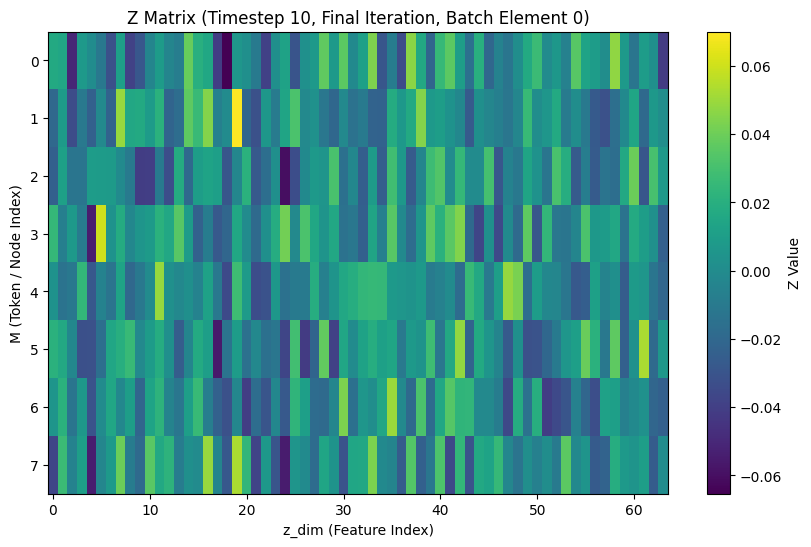

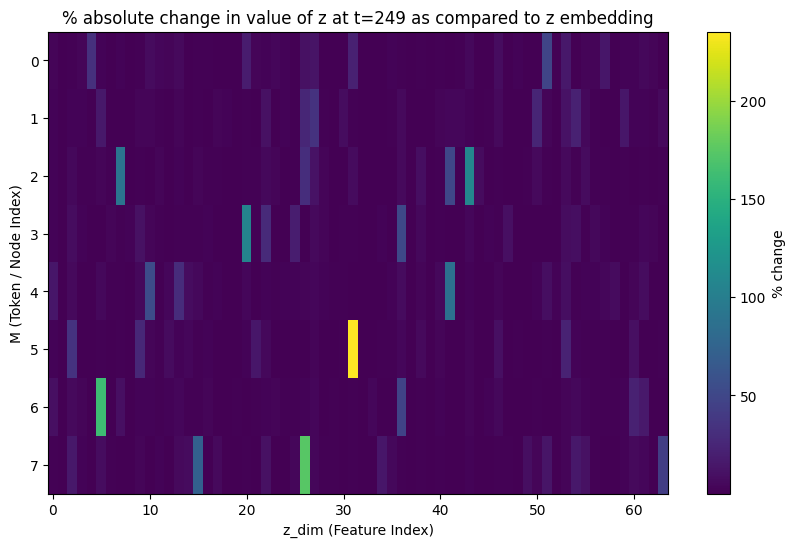

In [ ]:
z_base = state_dict["model.parameterization.encoder.z_base"]

z_base_plot = z_base.numpy() 
plt.figure(figsize=(10, 6))
plt.imshow(z_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label="Z Value")
plt.title(f"Z Matrix (Timestep {timestep}, Final Iteration, Batch Element 0)")
plt.xlabel("z_dim (Feature Index)")
plt.ylabel("M (Token / Node Index)")
plt.show()


latent_recursion_step = 0
timestep = 10
batch_element = 3
z_t249 = Z_iters[latent_recursion_step][timestep][batch_element].numpy()  # Final iteration, first timestep. Shape: (B, M, z_dim)
plotting=  np.abs(z_base_plot - z_t249) / np.abs(z_base_plot) * 100

plt.figure(figsize=(10, 6))
plt.imshow(plotting, aspect='auto', cmap='viridis')
plt.colorbar(label="% change")
plt.title(f"% absolute change in value of z at t=249 as compared to z embedding")
plt.xlabel("z_dim (Feature Index)")
plt.ylabel("M (Token / Node Index)")
plt.show()